## Predicting the Price of Used Toyota Corolla Cars Using Multiple Linear Regression

### Import necessary libraries

In [2]:
# import necessary libraries 
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as sm
import matplotlib.pylab as plt
import seaborn as sns

###  Load the data

In [3]:
cars_df = pd.read_csv('ToyotaCorolla.csv')

###  Display column/variable names

In [4]:
columns = list(cars_df.columns)
print("Variables in the data are: ")
print(columns)

Variables in the data are: 
['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


In [8]:
print("\nFirst 5 records in the data are:")
cars_df.head()


First 5 records in the data are:


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


### Print dimension of dataset

In [9]:
cars_df.shape

(1436, 39)

### Basic Statistics of the dataset

In [10]:
print(cars_df.describe())


Descriptive statistics of the dataset:
                Id         Price    Age_08_04    Mfg_Month     Mfg_Year  \
count  1436.000000   1436.000000  1436.000000  1436.000000  1436.000000   
mean    721.555014  10730.824513    55.947075     5.548747  1999.625348   
std     416.476890   3626.964585    18.599988     3.354085     1.540722   
min       1.000000   4350.000000     1.000000     1.000000  1998.000000   
25%     361.750000   8450.000000    44.000000     3.000000  1998.000000   
50%     721.500000   9900.000000    61.000000     5.000000  1999.000000   
75%    1081.250000  11950.000000    70.000000     8.000000  2001.000000   
max    1442.000000  32500.000000    80.000000    12.000000  2004.000000   

                  KM           HP    Met_Color    Automatic           CC  ...  \
count    1436.000000  1436.000000  1436.000000  1436.000000   1436.00000  ...   
mean    68533.259749   101.502089     0.674791     0.055710   1576.85585  ...   
std     37506.448872    14.981080     0.4

In [12]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


### Print datatypes

In [11]:
cars_df.dtypes

Id                    int64
Model                object
Price                 int64
Age_08_04             int64
Mfg_Month             int64
Mfg_Year              int64
KM                    int64
Fuel_Type            object
HP                    int64
Met_Color             int64
Color                object
Automatic             int64
CC                    int64
Doors                 int64
Cylinders             int64
Gears                 int64
Quarterly_Tax         int64
Weight                int64
Mfr_Guarantee         int64
BOVAG_Guarantee       int64
Guarantee_Period      int64
ABS                   int64
Airbag_1              int64
Airbag_2              int64
Airco                 int64
Automatic_airco       int64
Boardcomputer         int64
CD_Player             int64
Central_Lock          int64
Powered_Windows       int64
Power_Steering        int64
Radio                 int64
Mistlamps             int64
Sport_Model           int64
Backseat_Divider      int64
Metallic_Rim        

### Check for missing values

In [13]:
missing_values = cars_df.isnull().sum()
print("\nMissing values in the dataset:")
print(missing_values)


Missing values in the dataset:
Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


### 1. Split the data into training (60%), and validation (40%) datasets. Run a multiple linear regression with the outcome variable Price and predictor variables Age_08_04, KM,Fuel_Type, HP, Automatic, Doors, Quarterly_ Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, and Tow_Bar.

In [10]:
#Printing the train and test shape
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar']
outcome = 'Price'
x = cars_df[predictors]
y = cars_df[outcome]

# Create dummy variables for the categorical column 'Fuel_Type'
x = pd.get_dummies(x, columns=['Fuel_Type'], drop_first=True)

# Split the data into training and validation sets (60% training, 40% validation)
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.4, random_state=42)

print('Training set:', x_train.shape, 'Validation set:', x_valid.shape)


Training set: (861, 16) Validation set: (575, 16)


In [6]:
# Select the columns for regression analysis
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar']
outcome = 'Price'
x = cars_df[predictors]
y = cars_df[outcome]

# Create dummy variables for the categorical column 'Fuel_Type'
x = pd.get_dummies(x, columns=['Fuel_Type'], drop_first=True)

# Split the data into training and validation sets (60% training, 40% validation)
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.4, random_state=42)

# Fit the regression model y on x
cars_lm = LinearRegression()
cars_lm.fit(x_train, y_train)

# Print the regression model coefficients
intercept = cars_lm.intercept_
coefficients = pd.DataFrame({'Predictor': x.columns, 'Coefficient': cars_lm.coef_})

# Display the intercept, coefficients, and validation score
intercept, coefficients 

(10139.352665041826,
            Predictor  Coefficient
 0          Age_08_04  -111.692000
 1                 KM    -0.017576
 2                 HP    29.732254
 3          Automatic   535.405917
 4              Doors   165.883438
 5      Quarterly_Tax    16.944377
 6      Mfr_Guarantee   156.521758
 7   Guarantee_Period    73.685120
 8              Airco   248.610630
 9    Automatic_airco  3015.495036
 10         CD_Player   304.590689
 11   Powered_Windows   384.759273
 12       Sport_Model   341.192746
 13           Tow_Bar  -283.741189
 14  Fuel_Type_Diesel  1785.071135
 15  Fuel_Type_Petrol  1997.005756)

 **Analysis explained in the subsequent report**

### Correlation Matrix

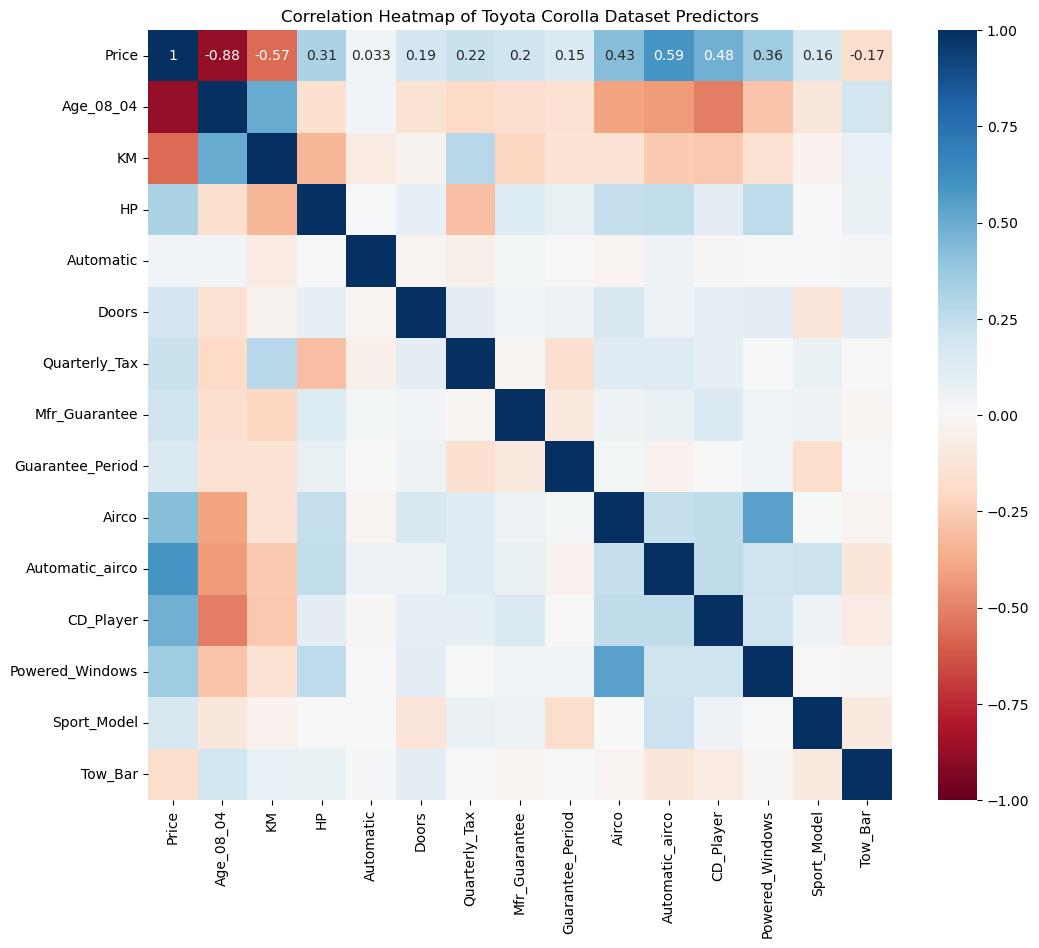

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'ToyotaCorolla.csv'
data = pd.read_csv(file_path)

# Selecting relevant columns for correlation analysis
selected_columns = ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 
                    'Doors', 'Quarterly_Tax', 'Mfr_Guarantee', 'Guarantee_Period', 
                    'Airco', 'Automatic_airco', 'CD_Player', 'Powered_Windows', 
                    'Sport_Model', 'Tow_Bar']

# Create a new dataframe with only numerical predictors
data_filtered = data[selected_columns]

# Compute the correlation matrix
corr_matrix = data_filtered.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Toyota Corolla Dataset Predictors')
plt.show()


### 1. a) What appear to be the three or four most important car specifications for predicting the car’s price?

In [5]:
#FINAL
# Select the columns for regression analysis
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar']
outcome = 'Price'
x = cars_df[predictors]
y = cars_df[outcome]

# Create dummy variables for the categorical column 'Fuel_Type'
x = pd.get_dummies(x, columns=['Fuel_Type'], drop_first=True)

# Split the data into training and validation sets (60% training, 40% validation)
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.4, random_state=42)

# Fit the regression model y on x
cars_lm = LinearRegression()
cars_lm.fit(x_train, y_train)

# Print the regression model coefficients
intercept = cars_lm.intercept_
coefficients = pd.DataFrame({'Predictor': x.columns, 'Coefficient': cars_lm.coef_})

# Calculate the validation score (R-squared)
validation_score = cars_lm.score(x_valid, y_valid)

# Display the intercept, coefficients, and validation score
(intercept, coefficients, validation_score)


(10139.352665041826,
            Predictor  Coefficient
 0          Age_08_04  -111.692000
 1                 KM    -0.017576
 2                 HP    29.732254
 3          Automatic   535.405917
 4              Doors   165.883438
 5      Quarterly_Tax    16.944377
 6      Mfr_Guarantee   156.521758
 7   Guarantee_Period    73.685120
 8              Airco   248.610630
 9    Automatic_airco  3015.495036
 10         CD_Player   304.590689
 11   Powered_Windows   384.759273
 12       Sport_Model   341.192746
 13           Tow_Bar  -283.741189
 14  Fuel_Type_Diesel  1785.071135
 15  Fuel_Type_Petrol  1997.005756,
 0.8820536251477762)

### Feature selection using backward elimination, forward selection and stepwise selection

In [17]:
import dmba
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection,stepwise_selection
from dmba import adjusted_r2_score, AIC_score , BIC_score

In [19]:
from dmba import backward_elimination, AIC_score

# BACKWARD ELIMINATION
def train_model(variables):
    model = LinearRegression()
    model.fit(x_train[variables], y_train)
    return model

def score_model(model, variables):
    return AIC_score(y_train, model.predict(x_train[variables]), model)

# Perform backward elimination
best_model, best_variables = backward_elimination(x_train.columns, train_model, score_model, verbose=True)

# Print the best subset of variables
print("Best Subset:", best_variables)


Variables: Age_08_04, KM, HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, Tow_Bar, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=14691.82
Step: score=14691.82, remove None
Best Subset: ['Age_08_04', 'KM', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 'Powered_Windows', 'Sport_Model', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


### In this case, backward elimination did not remove any predictors, implying that all variables contribute significantly to the model.

In [20]:
from dmba import forward_selection, AIC_score

# FORWARD SELECTION
# The initial model is the constant model, which requires special handling in train_model and score_model
def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(x_train[variables], y_train)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y_train, [y_train.mean()] * len(y_train), model, df=1)
    return AIC_score(y_train, model.predict(x_train[variables]), model)

# Perform forward selection
best_model, best_variables = forward_selection(x_train.columns, train_model, score_model, verbose=True)

# Print the best subset of variables
print("Best Subset:", best_variables)


Variables: Age_08_04, KM, HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, Tow_Bar, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=16582.26, constant
Step: score=15275.82, add Age_08_04
Step: score=15051.28, add Automatic_airco
Step: score=14950.25, add KM
Step: score=14885.50, add Quarterly_Tax
Step: score=14791.53, add HP
Step: score=14764.34, add Powered_Windows
Step: score=14754.50, add Doors
Step: score=14746.26, add Sport_Model
Step: score=14733.72, add Guarantee_Period
Step: score=14727.19, add Tow_Bar
Step: score=14721.07, add Automatic
Step: score=14715.83, add CD_Player
Step: score=14711.34, add Airco
Step: score=14708.49, add Fuel_Type_Petrol
Step: score=14692.92, add Fuel_Type_Diesel
Step: score=14691.82, add Mfr_Guarantee
Step: score=14691.82, add None
Best Subset: ['Age_08_04', 'Automatic_airco', 'KM', 'Quarterly_Tax', 'HP', 'Powered_Windows', 'Doors', 'Sport_Model', 'Guarantee_Period',

### This method starts with no predictors and adds them one at a time, selecting the ones that improve the model the most. It eventually arrived at the same set of 16 predictors as backward elimination.

 **Analysis explained in the subsequent report**

In [22]:
# STEPWISE 
best_model, best_variables = stepwise_selection(x_train.columns,train_model, score_model, verbose=True)
print("Best Subset:", best_variables)

Variables: Age_08_04, KM, HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, Tow_Bar, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=16582.26, constant
Step: score=15275.82, add Age_08_04
Step: score=15051.28, add Automatic_airco
Step: score=14950.25, add KM
Step: score=14885.50, add Quarterly_Tax
Step: score=14791.53, add HP
Step: score=14764.34, add Powered_Windows
Step: score=14754.50, add Doors
Step: score=14746.26, add Sport_Model
Step: score=14733.72, add Guarantee_Period
Step: score=14727.19, add Tow_Bar
Step: score=14721.07, add Automatic
Step: score=14715.83, add CD_Player
Step: score=14711.34, add Airco
Step: score=14708.49, add Fuel_Type_Petrol
Step: score=14692.92, add Fuel_Type_Diesel
Step: score=14691.82, add Mfr_Guarantee
Step: score=14691.82, unchanged None
Best Subset: ['Age_08_04', 'Automatic_airco', 'KM', 'Quarterly_Tax', 'HP', 'Powered_Windows', 'Doors', 'Sport_Model', 'Guarantee_Pe

### A combination of both forward selection and backward elimination. It started with an empty model and added/removes predictors iteratively. The best subset identified was the same as that found in forward selection.

### 1. b) Using metrics you consider useful, assess the performance of the model in predicting prices.

In [13]:
# Define the predictors and outcome
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar']
outcome = 'Price'

# Create the features (X) and target variable (y)
X = cars_df[predictors]  # Use the original DataFrame to select predictors
X = pd.get_dummies(X, columns=['Fuel_Type'], drop_first=True)  # Create dummy variables
y = cars_df[outcome]  # Target variable

# Split the data into training (60%) and validation (40%) sets
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=42)

# Print the shape of the training and validation sets
print('Training set:', train_X.shape, 'Validation set:', valid_X.shape)


Training set: (861, 16) Validation set: (575, 16)


In [14]:
from dmba import regressionSummary
from sklearn.linear_model import LinearRegression

# Define the outcome and best subset of predictors, assuming dummy variables for 'Fuel_Type' have been created
predictors = ['Age_08_04', 'KM', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'] 

# Extract the training and validation sets with the appropriate predictors
X = train_X[predictors]
y = train_y

# Fit the regression model on the training set
cars_lm = LinearRegression()
cars_lm.fit(X, y)

# Print the regression model coefficients
print('Intercept:', cars_lm.intercept_)
print(pd.DataFrame({'Predictor': X.columns, 'Coefficient': cars_lm.coef_}))

# Print performance measures (training set)
print("\nModel performance on training data:")
regressionSummary(train_y, cars_lm.predict(train_X[predictors]))

# Predict prices in the validation set
cars_lm_pred = cars_lm.predict(valid_X[predictors])
result = pd.DataFrame({'Predicted': cars_lm_pred, 'Actual': valid_y, 'Residual': valid_y - cars_lm_pred})

# Print performance measures (validation set)
print("\nModel performance on validation data:")
regressionSummary(valid_y, cars_lm_pred)


Intercept: 10139.352665041826
           Predictor  Coefficient
0          Age_08_04  -111.692000
1                 KM    -0.017576
2                 HP    29.732254
3          Automatic   535.405917
4              Doors   165.883438
5      Quarterly_Tax    16.944377
6      Mfr_Guarantee   156.521758
7   Guarantee_Period    73.685120
8              Airco   248.610630
9    Automatic_airco  3015.495036
10         CD_Player   304.590689
11   Powered_Windows   384.759273
12       Sport_Model   341.192746
13           Tow_Bar  -283.741189
14  Fuel_Type_Diesel  1785.071135
15  Fuel_Type_Petrol  1997.005756

Model performance on training data:

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1202.2957
            Mean Absolute Error (MAE) : 912.3493
          Mean Percentage Error (MPE) : -1.0741
Mean Absolute Percentage Error (MAPE) : 9.0636

Model performance on validation data:

Regression statistics

                      Mean

 **Analysis explained in the subsequent report**

## With adjusted R2 score

In [15]:
from dmba import regressionSummary

predictors = ['Age_08_04', 'KM', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax', 
              'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player', 
              'Powered_Windows', 'Sport_Model', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']

# Extract subset of predictors from the training and validation sets
X_train_subset = train_X[predictors]
X_valid_subset = valid_X[predictors]
y_train_subset = train_y
y_valid_subset = valid_y

# Fit the regression model on the training set
cars_lm = LinearRegression()
cars_lm.fit(X_train_subset, y_train_subset)

# Calculate R-squared for training and validation sets
r2_train = cars_lm.score(X_train_subset, y_train_subset)
r2_valid = cars_lm.score(X_valid_subset, y_valid_subset)

# Calculate adjusted R-squared for training and validation sets
n_train = X_train_subset.shape[0]  
p_train = X_train_subset.shape[1]  
adjusted_r2_train = 1 - ((1 - r2_train) * (n_train - 1) / (n_train - p_train - 1))

n_valid = X_valid_subset.shape[0]  
p_valid = X_valid_subset.shape[1]  
adjusted_r2_valid = 1 - ((1 - r2_valid) * (n_valid - 1) / (n_valid - p_valid - 1))

# Print adjusted R-squared for training and validation sets
print(f'Adjusted R-squared (Training): {adjusted_r2_train}')
print(f'Adjusted R-squared (Validation): {adjusted_r2_valid}')

# Model performance on the training set
print("\nModel performance on training data:")
regressionSummary(y_train_subset, cars_lm.predict(X_train_subset))

# Predict prices on the validation set
cars_lm_pred = cars_lm.predict(X_valid_subset)
result = pd.DataFrame({'Predicted': cars_lm_pred, 'Actual': y_valid_subset, 
                       'Residual': y_valid_subset - cars_lm_pred})

# Model performance on the validation set
print("\nModel performance on validation data:")
regressionSummary(y_valid_subset, cars_lm_pred)


Adjusted R-squared (Training): 0.8907399551191477
Adjusted R-squared (Validation): 0.8786716502416192

Model performance on training data:

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1202.2957
            Mean Absolute Error (MAE) : 912.3493
          Mean Percentage Error (MPE) : -1.0741
Mean Absolute Percentage Error (MAPE) : 9.0636

Model performance on validation data:

Regression statistics

                      Mean Error (ME) : -116.8193
       Root Mean Squared Error (RMSE) : 1221.0390
            Mean Absolute Error (MAE) : 890.7991
          Mean Percentage Error (MPE) : -2.0670
Mean Absolute Percentage Error (MAPE) : 8.7606
